# Multi-Market Risk & Volatility analysis

In [42]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import plotly.express as px

In [43]:
# Assets, indices and macros
us_equities = ['AAPL', 'AMZN', 'JPM', 'JNJ', 'XOM', 'WMT', 'GOOGL']  # US Market
in_equities = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ITC.NS', 'LT.NS', 'M&M.NS',  'SUNPHARMA.NS'] # Indian Market
indices = ['^GSPC', '^IXIC', '^NSEI'] 
macro = ['INR=X'] 

#  master list for the API call
all_tickers = indices + us_equities + in_equities + macro

# Set our time horizon using Pandas (Bypassing the standard datetime library completely!)
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
start_date = (pd.Timestamp.today() - pd.DateOffset(years=5)).strftime('%Y-%m-%d')

print(f"Target Timeframe: {start_date} to {end_date}")
print(f"Tickers to fetch ({len(all_tickers)} total): {all_tickers}")

Target Timeframe: 2021-03-06 to 2026-03-06
Tickers to fetch (18 total): ['^GSPC', '^IXIC', '^NSEI', 'AAPL', 'AMZN', 'JPM', 'JNJ', 'XOM', 'WMT', 'GOOGL', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'ITC.NS', 'LT.NS', 'M&M.NS', 'SUNPHARMA.NS', 'INR=X']


In [44]:
# Cell 3
raw_data = {}

print("Initializing API calls to Yahoo Finance...")

for ticker in all_tickers:
    print(f"Pulling {ticker}...")
    # Fetch the data silently
    ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if not ticker_data.empty:
        # yfinance constantly changes its output structure. 
        # If it returns a MultiIndex, we aggressively flatten it to just the top-level names (e.g., 'Close', 'Volume').
        if isinstance(ticker_data.columns, pd.MultiIndex):
            ticker_data.columns = ticker_data.columns.get_level_values(0)
        
        # Fallback Logic: Try to get 'Adj Close'. If the API didn't provide it (common with forex), use 'Close'.
        if 'Adj Close' in ticker_data.columns:
            target_col = 'Adj Close'
        elif 'Close' in ticker_data.columns:
            target_col = 'Close'
        else:
            print(f"  -> WARNING: No price column found for {ticker}. Skipping.")
            continue
            
        price_series = ticker_data[target_col]
        
        # If flattening caused duplicate column names somehow, force it to just take the first one
        if isinstance(price_series, pd.DataFrame):
            price_series = price_series.iloc[:, 0]
            
        # Strip the timezone data to prevent alignment errors between US and India
        price_series.index = price_series.index.tz_localize(None)
        raw_data[ticker] = price_series

print("\nAll data successfully downloaded and stored in the raw_data dictionary!")

Initializing API calls to Yahoo Finance...
Pulling ^GSPC...
Pulling ^IXIC...


Pulling ^NSEI...
Pulling AAPL...
Pulling AMZN...
Pulling JPM...
Pulling JNJ...
Pulling XOM...
Pulling WMT...
Pulling GOOGL...
Pulling RELIANCE.NS...
Pulling TCS.NS...
Pulling HDFCBANK.NS...
Pulling ITC.NS...
Pulling LT.NS...
Pulling M&M.NS...
Pulling SUNPHARMA.NS...
Pulling INR=X...

All data successfully downloaded and stored in the raw_data dictionary!


In [45]:
# Convert our dictionary of individual Series into a single unified Pandas DataFrame
df = pd.DataFrame(raw_data)

# Sort the index chronologically to ensure data flows correctly
df.sort_index(inplace=True)

# Handle Missing Data: Forward Fill (ffill)
# This propagates the last valid observation forward to fill the NaN gaps caused by market holidays
df.ffill(inplace=True)

# Drop the very first few rows if they contain NaNs 
# (since ffill cannot fill backward if the dataset starts on a holiday for one market)
df.dropna(inplace=True)

print("Data Ingestion & Alignment Complete!")
print("-" * 40)
print(f"Total Unified Trading Days Captured: {len(df)}")
print("\nFirst 5 rows of our unified, cross-market dataset:")

# display() renders a beautifully formatted table in Jupyter
display(df.head())

Data Ingestion & Alignment Complete!
----------------------------------------
Total Unified Trading Days Captured: 1303

First 5 rows of our unified, cross-market dataset:


,^GSPC,^IXIC,^NSEI,AAPL,AMZN,JPM,JNJ,XOM,WMT,GOOGL,RELIANCE.NS,TCS.NS,HDFCBANK.NS,ITC.NS,LT.NS,M&M.NS,SUNPHARMA.NS,INR=X
Date,,,,,,,,,,,,,,,,,,
2021-03-08,3821.350098,12609.160156,14956.200195,113.334129,147.597504,134.656616,136.683411,50.259533,39.826256,99.622284,993.513306,2643.341064,719.616699,163.511337,1437.837524,811.851257,585.166931,73.133400
2021-03-09,3875.439941,13073.820312,15098.400391,117.941124,153.142502,133.705536,136.943924,49.483383,40.140808,101.252960,993.490479,2682.019531,739.980957,163.354080,1431.289917,812.805176,583.073059,73.330002
2021-03-10,3898.810059,13068.830078,15174.799805,116.859993,152.882004,136.611633,138.203094,51.002647,41.165436,101.046028,989.364319,2699.601562,736.784241,162.332153,1446.378052,824.062317,595.827087,72.775902
2021-03-11,3939.340088,13398.669922,15174.799805,118.788498,155.679504,135.898315,138.194366,50.622837,41.149857,104.239395,989.364319,2699.601562,736.784241,162.332153,1446.378052,824.062317,595.827087,72.706001
2021-03-12,3943.340088,13319.860352,15030.950195,117.882675,154.474503,137.509827,138.593826,51.167789,41.769619,101.731354,969.254700,2688.173096,734.984558,161.310211,1436.698853,816.430298,584.024719,72.639000


Currency Normalization:

In [46]:
df_usd = df.copy()

# These are the assets currently priced in INR
inr_assets = in_equities + ['^NSEI']

print("Normalizing Indian asset prices to USD...")

for asset in inr_assets:
    # Ensure the columns exist before doing the math
    if asset in df_usd.columns and 'INR=X' in df_usd.columns:
        # Math: INR Price / (INR per 1 USD) = USD Price
        df_usd[asset] = df_usd[asset] / df_usd['INR=X']

# Now that all assets are priced in USD, the exchange rate column has done its job.
# We drop it so it doesn't mess up our future correlation matrix.
if 'INR=X' in df_usd.columns:
    df_usd.drop(columns=['INR=X'], inplace=True)

print("Currency normalization complete! All assets are now in USD.")
display(df_usd.head())

Normalizing Indian asset prices to USD...
Currency normalization complete! All assets are now in USD.


,^GSPC,^IXIC,^NSEI,AAPL,AMZN,JPM,JNJ,XOM,WMT,GOOGL,RELIANCE.NS,TCS.NS,HDFCBANK.NS,ITC.NS,LT.NS,M&M.NS,SUNPHARMA.NS
Date,,,,,,,,,,,,,,,,,
2021-03-08,3821.350098,12609.160156,204.505742,113.334129,147.597504,134.656616,136.683411,50.259533,39.826256,99.622284,13.584946,36.144102,9.839782,2.235796,19.660477,11.100964,8.001364
2021-03-09,3875.439941,13073.820312,205.896632,117.941124,153.142502,133.705536,136.943924,49.483383,40.140808,101.252960,13.548213,36.574655,10.091108,2.227657,19.518476,11.084210,7.951357
2021-03-10,3898.810059,13068.830078,208.514074,116.859993,152.882004,136.611633,138.203094,51.002647,41.165436,101.046028,13.594669,37.094718,10.124014,2.230576,19.874409,11.323286,8.187148
2021-03-11,3939.340088,13398.669922,208.714543,118.788498,155.679504,135.898315,138.194366,50.622837,41.149857,104.239395,13.607739,37.130381,10.133747,2.232720,19.893517,11.334172,8.195019
2021-03-12,3943.340088,13319.860352,206.926723,117.882675,154.474503,137.509827,138.593826,51.167789,41.769619,101.731354,13.343448,37.007298,10.118319,2.220711,19.778616,11.239559,8.040099


Daily Logarithmic Returns Calculation

In [47]:
# ==========================================
# Cell 6: Daily Logarithmic Returns Calculation
# ==========================================
print("Transforming prices into daily logarithmic returns...")

# Using NumPy and Pandas vectorization to calculate log returns instantly across all columns
log_returns = np.log(df_usd / df_usd.shift(1))

# The shift(1) operation creates a row of NaNs at the very beginning. We drop it.
log_returns.dropna(inplace=True)

print("Transformation complete!")
print("-" * 40)
display(log_returns.head())

Transforming prices into daily logarithmic returns...
Transformation complete!
----------------------------------------


,^GSPC,^IXIC,^NSEI,AAPL,AMZN,JPM,JNJ,XOM,WMT,GOOGL,RELIANCE.NS,TCS.NS,HDFCBANK.NS,ITC.NS,LT.NS,M&M.NS,SUNPHARMA.NS
Date,,,,,,,,,,,,,,,,,
2021-03-09,0.014055,0.036188,0.006778,0.039845,0.036880,-0.007088,0.001904,-0.015563,0.007867,0.016236,-0.002708,0.011842,0.025221,-0.003647,-0.007249,-0.001510,-0.006269
2021-03-10,0.006012,-0.000382,0.012632,-0.009209,-0.001702,0.021502,0.009153,0.030241,0.025205,-0.002046,0.003423,0.014119,0.003256,0.001309,0.018071,0.021340,0.029223
2021-03-11,0.010342,0.024925,0.000961,0.016368,0.018133,-0.005235,-0.000063,-0.007475,-0.000379,0.031114,0.000961,0.000961,0.000961,0.000961,0.000961,0.000961,0.000961
2021-03-12,0.001015,-0.005899,-0.008603,-0.007655,-0.007770,0.011788,0.002886,0.010707,0.014949,-0.024355,-0.019613,-0.003320,-0.001524,-0.005393,-0.005793,-0.008383,-0.019085
2021-03-15,0.006471,0.010445,-0.007378,0.024163,-0.002531,-0.005008,0.005125,-0.025827,-0.005158,0.002163,-0.014123,0.002073,-0.015733,0.000612,-0.020788,-0.014016,-0.013894


30 day Rolling volatality

Calculating 30-day rolling annualized volatility...


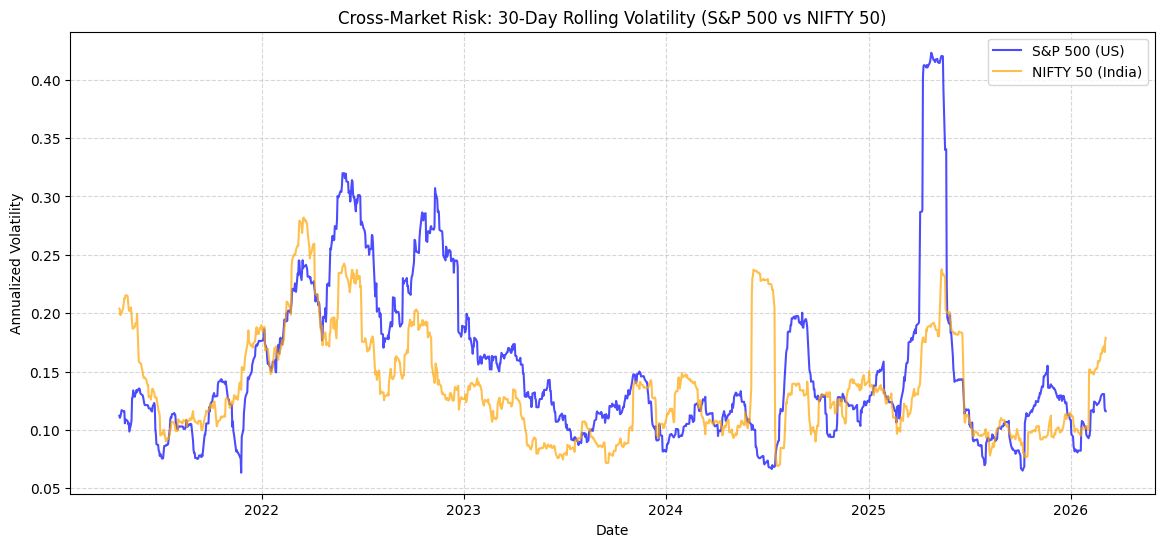

In [48]:
print("Calculating 30-day rolling annualized volatility...")

# Calculate the rolling 30-day standard deviation and annualize it
# window=30 means it looks at the past 30 trading days for each data point
rolling_volatility = log_returns.rolling(window=30).std() * np.sqrt(252)

# Drop the first 29 rows since they won't have a full 30-day window to calculate
rolling_volatility.dropna(inplace=True)

# Let's plot the risk comparison between the US and Indian benchmark indices
plt.figure(figsize=(14, 6))
plt.plot(rolling_volatility.index, rolling_volatility['^GSPC'], label='S&P 500 (US)', color='blue', alpha=0.7)
plt.plot(rolling_volatility.index, rolling_volatility['^NSEI'], label='NIFTY 50 (India)', color='orange', alpha=0.7)

plt.title('Cross-Market Risk: 30-Day Rolling Volatility (S&P 500 vs NIFTY 50)')
plt.ylabel('Annualized Volatility')
plt.xlabel('Date')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Cross-Asset Correlation matrix

Generating Cross-Market Correlation Heatmap...


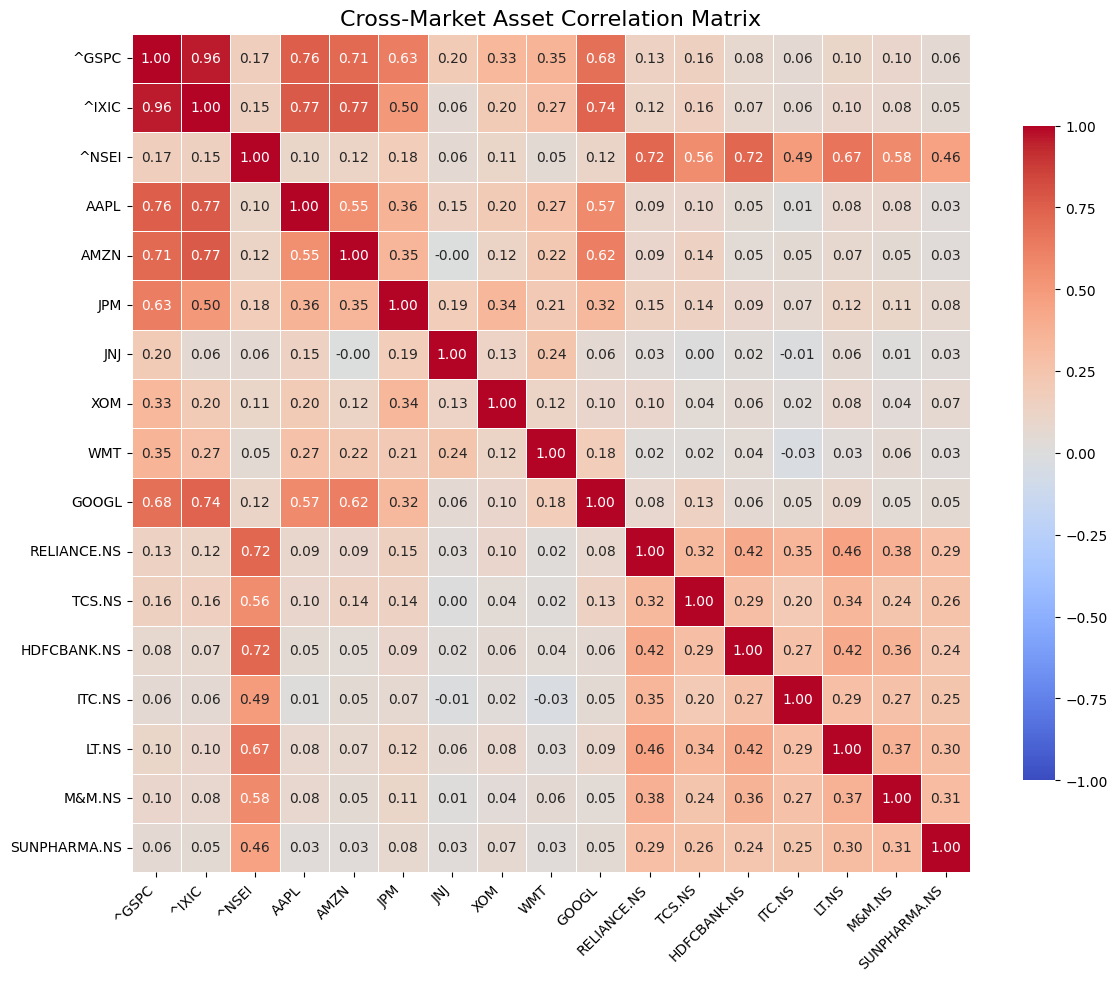

In [49]:
print("Generating Cross-Market Correlation Heatmap...")

correlation_matrix = log_returns.corr() # Calculating the correlation matrix of the log returns

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))
# cmap='coolwarm' gives a great blue (negative correlation) to red (positive correlation) gradient
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Cross-Market Asset Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Institutional Risk matrix

In [50]:
print("Calculating Value at Risk (VaR) and Sharpe Ratio...")

# 1. Historical Value at Risk (95% Confidence)
# By finding the 5th percentile of daily returns, we isolate the worst 5% of trading days.
var_95 = log_returns.apply(lambda x: np.percentile(x.dropna(), 5))

# 2. Annualized Return & Volatility
# We multiply by 252 (the average number of trading days in a year) to annualize daily metrics.
annual_return = log_returns.mean() * 252
annual_volatility = log_returns.std() * np.sqrt(252)

# 3. Sharpe Ratio
# We will assume a nominal 4% (0.04) global risk-free rate for comparative purposes.
risk_free_rate = 0.04 
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# Combine everything into a clean summary DataFrame
risk_metrics = pd.DataFrame({
    '95% Daily VaR': var_95,
    'Annualized Return': annual_return,
    'Annualized Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio
})

# Sort by Sharpe Ratio to see which asset performed best relative to its risk
risk_metrics.sort_values(by='Sharpe Ratio', ascending=False, inplace=True)

print("\nRisk Metrics Summary:")
# Using Pandas styling to add a heatmap gradient to the Sharpe Ratio column
display(risk_metrics.style.format("{:.4f}").background_gradient(cmap='RdYlGn', subset=['Sharpe Ratio']))

Calculating Value at Risk (VaR) and Sharpe Ratio...

Risk Metrics Summary:


,95% Daily VaR,Annualized Return,Annualized Volatility,Sharpe Ratio
WMT,-0.0181,0.2187,0.2075,0.8613
M&M.NS,-0.0267,0.2295,0.2741,0.6914
XOM,-0.0265,0.2126,0.2614,0.6604
SUNPHARMA.NS,-0.0209,0.1711,0.2072,0.6329
GOOGL,-0.0288,0.2139,0.3012,0.5774
LT.NS,-0.0220,0.1552,0.2380,0.4841
JPM,-0.0235,0.1508,0.2389,0.4640
AAPL,-0.0273,0.1609,0.2697,0.4484
^GSPC,-0.0162,0.1124,0.1649,0.4392
JNJ,-0.0155,0.1087,0.1633,0.4205


Interactive Cumulative Returns Dashboard

In [ ]:
print("Generating Interactive Plotly Dashboard...")

# 1. Calculate Cumulative Returns
# We take our daily log returns, keep a running sum (cumsum), and exponentiate it 
# to turn it back into a standard growth multiplier.
cumulative_returns = np.exp(log_returns.cumsum())

fig = px.line(cumulative_returns, x=cumulative_returns.index, y=cumulative_returns.columns,
              title='Relative Performance Dynamics (Base $1.00 Investment)(Time Period: 5 Years)',
              labels={'value': 'Cumulative Return Multiplier', 'Date': 'Date (Slide to required time periods)', 'variable': 'Ticker'})

# range slider at the bottom to zoom in on specific market time periods (like 2020 or 2022)
fig.update_xaxes(rangeslider_visible=True)

# Update hover mechanics so when you hover over a date, it shows the exact value for ALL stocks that day
fig.update_layout(hovermode='x unified', 
                  legend_title_text='Assets (Click to Toggle)',
                  template='plotly_dark') # 'plotly_dark' gives it a sleek, professional terminal look

# Render the interactive chart right here in the notebook
fig.show(renderer="browser")

Generating Interactive Plotly Dashboard...
